# Breakfast Basket — Wage-Adjusted Food Inflation Classification
## Logistic Regression Model with GNI Integration | DSS740 Group 4

**Author:** Blake  
**Model:** Logistic Regression  
**Datasets:**
- *Global Grocery Inflation 2025–2026* — 10,248 rows × 27 columns (122 cities × 14 items × 6 months)
- *World Bank GNI per Capita* — Atlas method, current USD (merged by country)

---
### Project Overview
This model classifies whether a household in a given city is **wage-burdened by food costs** — i.e.,
whether its breakfast basket cost represents an above-median share of weekly income.

**Target variable:** `Wage_Burdened`
- Computed as: `Basket_to_Income_Ratio = Breakfast_Basket_USD / (GNI_Per_Capita / 52)`
- **1 (Wage Burdened)** = ratio exceeds the global median across all city-item-month observations
- **0 (Not Burdened)** = ratio is at or below the global median

This is a direct implementation of the proposal's wage-adjusted classification objective:
food inflation is evaluated *relative to income*, not just in absolute price terms.


---
## 0. Imports & Setup


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, log_loss)
from scipy import stats

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('shap not installed — Section 8 will be skipped. Run: pip install shap')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42

# ── Update these paths to match your local file locations ──
BASKET_PATH = '/Users/user/Desktop/SJU/DSS740/team 4 repo/DSS740_team_4/data/breakfast basket.csv'
GNI_PATH    = '/Users/user/Desktop/SJU/DSS740/team 4 repo/DSS740_team_4/data/GNI.csv'

print('Libraries loaded successfully.')


Libraries loaded successfully.


---
## 1. Data Loading & Merging

### 1a. Load Datasets
The World Bank GNI dataset uses `Country Name` — a manual mapping dictionary resolves
the 10 country name mismatches between the two sources (e.g. 'Turkey' → 'Turkiye',
'South Korea' → 'Korea, Rep.').


In [5]:
# ── Load breakfast basket dataset ──
df = pd.read_csv(BASKET_PATH)
print(f'Basket dataset  : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Cities          : {df["City"].nunique()}')
print(f'Countries       : {df["Country"].nunique()}')
print(f'Food items      : {df["Item"].nunique()}')
print(f'Months          : {sorted(df["Month"].unique())}')

# ── Load World Bank GNI per capita ──
gni_raw = pd.read_csv(GNI_PATH, skiprows=4)
gni = gni_raw[['Country Name','2024','2023','2022']].copy()
gni.columns = ['Country_Name','GNI_2024','GNI_2023','GNI_2022']
# Use most recent available year per country
gni['GNI_Per_Capita'] = gni['GNI_2024'].fillna(gni['GNI_2023']).fillna(gni['GNI_2022'])
gni = gni.dropna(subset=['GNI_Per_Capita'])
print(f'\nGNI dataset     : {len(gni)} countries with valid GNI values')

# ── Country name mapping for mismatches ──
COUNTRY_MAP = {
    'Czech Republic' : 'Czechia',
    'Egypt'          : 'Egypt, Arab Rep.',
    'Hong Kong'      : 'Hong Kong SAR, China',
    'Iran'           : 'Iran, Islamic Rep.',
    'Russia'         : 'Russian Federation',
    'Slovakia'       : 'Slovak Republic',
    'South Korea'    : 'Korea, Rep.',
    'Taiwan'         : 'Taiwan, China',
    'Turkey'         : 'Turkiye',
    'Vietnam'        : 'Viet Nam'
}

# ── Merge ──
gni_lookup      = gni.set_index('Country_Name')['GNI_Per_Capita']
df['GNI_Per_Capita'] = df['Country'].replace(COUNTRY_MAP).map(gni_lookup)

matched   = df['GNI_Per_Capita'].notna().sum()
unmatched = df['GNI_Per_Capita'].isna().sum()
print(f'\nMerge results   : {matched:,} rows matched ({matched/len(df)*100:.1f}%)')
print(f'Unmatched rows  : {unmatched} (Taiwan — excluded from model)')

# Drop unmatched rows (Taiwan only)
df = df.dropna(subset=['GNI_Per_Capita']).copy()
print(f'Final dataset   : {len(df):,} rows')
df.head(3)


Basket dataset  : 10,248 rows × 27 columns
Cities          : 122
Countries       : 80
Food items      : 14
Months          : ['2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03']

GNI dataset     : 249 countries with valid GNI values

Merge results   : 10,164 rows matched (99.2%)
Unmatched rows  : 84 (Taiwan — excluded from model)
Final dataset   : 10,164 rows


,City,Country,ISO_Country_Code,Region,Continent,Month,Month_Name,Item,Item_Key,Item_Category,...,FAO_Index_Value,FAO_Index_Date,FAO_YoY_Change_Pct,USDA_All_Food_Forecast_Pct,USDA_Food_At_Home_Pct,Data_Collection_Date,Source_URL,Population_Estimate,Breakfast_Basket_USD,GNI_Per_Capita
0,New York,United States,USA,North America,North America,2025-10,October 2025,Milk (1 Liter),Milk_1L,Dairy,...,127.1,October 2025,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,16.18,83490.0
1,New York,United States,USA,North America,North America,2025-11,November 2025,Milk (1 Liter),Milk_1L,Dairy,...,126.2,November 2025,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,16.40,83490.0
2,New York,United States,USA,North America,North America,2025-12,December 2025,Milk (1 Liter),Milk_1L,Dairy,...,125.8,December 2025,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,17.02,83490.0


### 1b. Feature Engineering & Target Creation

**New features engineered:**
- `Log_Price_USD` — log-transformed item price (reduces right skew)
- `Log_Population` — log-transformed city population
- `Log_GNI` — log-transformed GNI per capita (compresses income scale)
- `Basket_to_Income_Ratio` — breakfast basket cost as a share of estimated weekly income
  `= Breakfast_Basket_USD / (GNI_Per_Capita / 52)`

**Target — `Wage_Burdened`:**
Cities where the basket-to-income ratio exceeds the global median are classified as **Wage Burdened (1)**.
This directly measures whether food costs are disproportionately high relative to local wages.


In [6]:
# ── Log transforms ──
df['Log_Price_USD']  = np.log1p(df['Price_USD'])
df['Log_Population'] = np.log1p(df['Population_Estimate'])
df['Log_GNI']        = np.log1p(df['GNI_Per_Capita'])

# ── Wage-adjusted affordability ratio ──
# Weekly income proxy = annual GNI / 52
df['Basket_to_Income_Ratio'] = df['Breakfast_Basket_USD'] / (df['GNI_Per_Capita'] / 52)

# ── Label encode categoricals ──
for col, name in [('Item','Item_Enc'),('Continent','Continent_Enc'),
                  ('Region','Region_Enc'),('Item_Category','Category_Enc')]:
    le = LabelEncoder()
    df[name] = le.fit_transform(df[col])

# ── Target variable ──
median_ratio        = df['Basket_to_Income_Ratio'].median()
df['Wage_Burdened'] = (df['Basket_to_Income_Ratio'] > median_ratio).astype(int)

print(f'Median basket-to-income ratio : {median_ratio:.4f}')
print(f'  → Cities above this ratio are classified as Wage Burdened')
vc = df['Wage_Burdened'].value_counts()
print(f'\nWage Burdened (1) : {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)')
print(f'Not Burdened  (0) : {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)')
print(f'Class balance     : near-perfect — no SMOTE needed')

FEATURES = ['Log_Price_USD', 'Exchange_Rate', 'Log_Population',
            'Log_GNI', 'Basket_to_Income_Ratio',
            'Item_Enc', 'Continent_Enc', 'Region_Enc', 'Category_Enc']
TARGET   = 'Wage_Burdened'

X = df[FEATURES].values
y = df[TARGET].values

print(f'\nFeature matrix : {X.shape}')
print(f'Features       : {FEATURES}')


Median basket-to-income ratio : 0.0212
  → Cities above this ratio are classified as Wage Burdened

Wage Burdened (1) : 5,082  (50.0%)
Not Burdened  (0) : 5,082  (50.0%)
Class balance     : near-perfect — no SMOTE needed

Feature matrix : (10164, 9)
Features       : ['Log_Price_USD', 'Exchange_Rate', 'Log_Population', 'Log_GNI', 'Basket_to_Income_Ratio', 'Item_Enc', 'Continent_Enc', 'Region_Enc', 'Category_Enc']


---
## 2. Exploratory Data Analysis


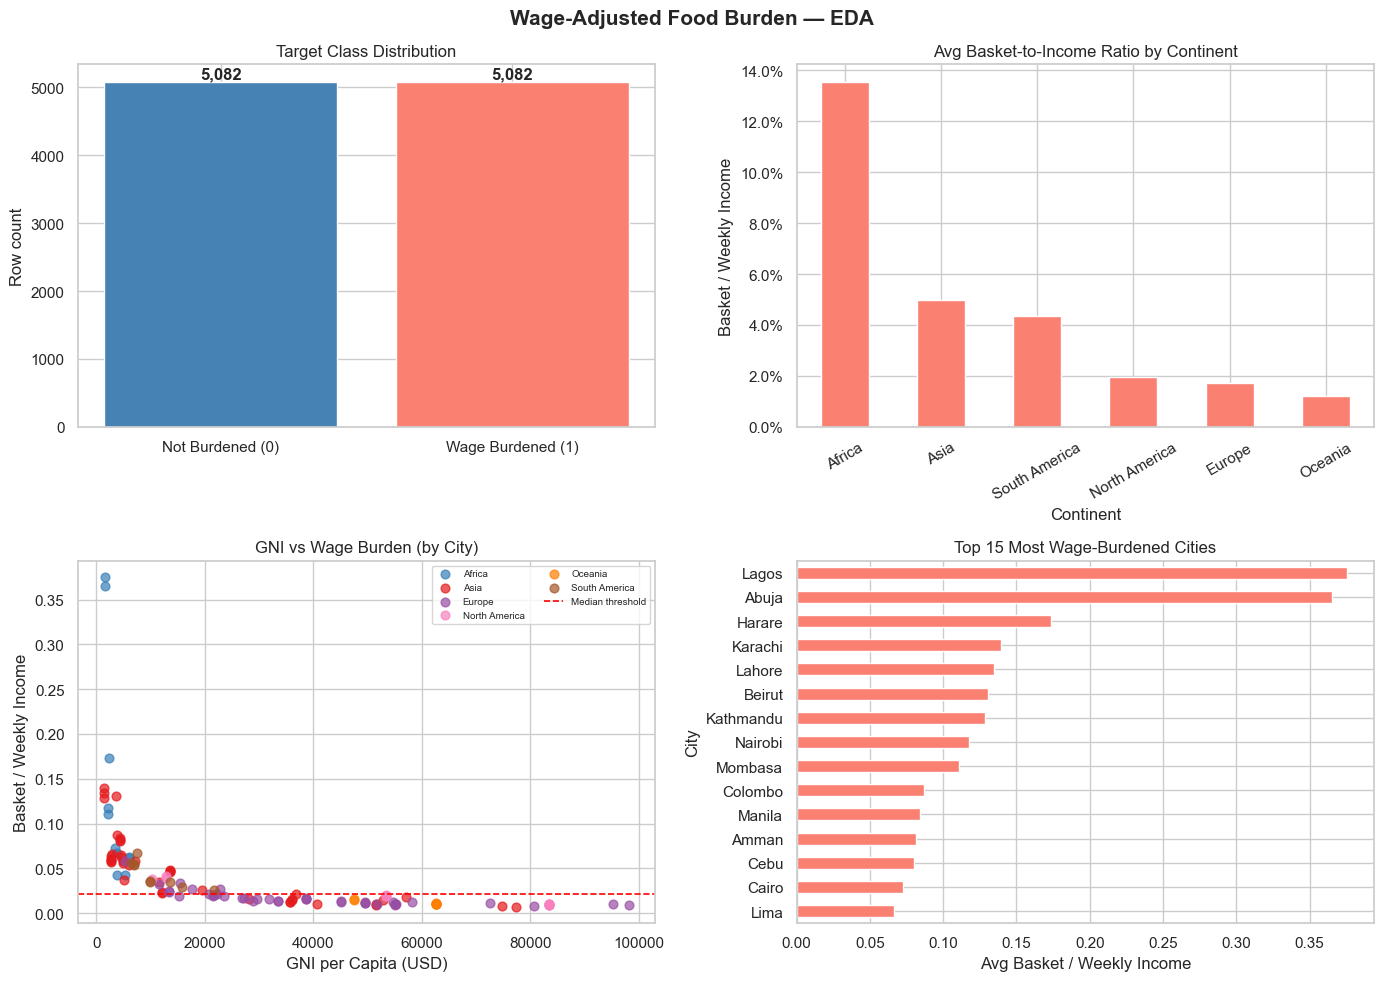

EDA saved → eda_plots.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Wage-Adjusted Food Burden — EDA', fontsize=15, fontweight='bold')

# Plot 1: Class balance
vc = df['Wage_Burdened'].value_counts()
axes[0,0].bar(['Not Burdened (0)','Wage Burdened (1)'],
              [vc[0], vc[1]], color=['steelblue','salmon'], edgecolor='white')
axes[0,0].set_title('Target Class Distribution')
axes[0,0].set_ylabel('Row count')
for i,v in enumerate([vc[0],vc[1]]):
    axes[0,0].text(i, v+50, f'{v:,}', ha='center', fontweight='bold')

# Plot 2: Avg basket-to-income ratio by continent
burden = df.groupby('Continent')['Basket_to_Income_Ratio'].mean().sort_values(ascending=False)
burden.plot(kind='bar', ax=axes[0,1], color='salmon', edgecolor='white')
axes[0,1].set_title('Avg Basket-to-Income Ratio by Continent')
axes[0,1].set_ylabel('Basket / Weekly Income')
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0,1].tick_params(axis='x', rotation=30)

# Plot 3: GNI vs Basket-to-income ratio (scatter)
city_df = df.groupby('City').agg(
    GNI=('GNI_Per_Capita','first'),
    Ratio=('Basket_to_Income_Ratio','mean'),
    Continent=('Continent','first')
).reset_index()
cont_colors = {c:plt.cm.Set1(i/len(city_df['Continent'].unique()))
               for i,c in enumerate(city_df['Continent'].unique())}
for cont, grp in city_df.groupby('Continent'):
    axes[1,0].scatter(grp['GNI'], grp['Ratio'], label=cont,
                      alpha=0.7, s=40, color=cont_colors[cont])
axes[1,0].axhline(median_ratio, color='red', linestyle='--', linewidth=1.2, label='Median threshold')
axes[1,0].set_xlabel('GNI per Capita (USD)')
axes[1,0].set_ylabel('Basket / Weekly Income')
axes[1,0].set_title('GNI vs Wage Burden (by City)')
axes[1,0].legend(fontsize=7, ncol=2)

# Plot 4: Top 15 most burdened cities
top_burden = df.groupby('City')['Basket_to_Income_Ratio'].mean().sort_values(ascending=False).head(15)
top_burden.plot(kind='barh', ax=axes[1,1], color='salmon', edgecolor='white')
axes[1,1].set_title('Top 15 Most Wage-Burdened Cities')
axes[1,1].set_xlabel('Avg Basket / Weekly Income')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA saved → eda_plots.png')


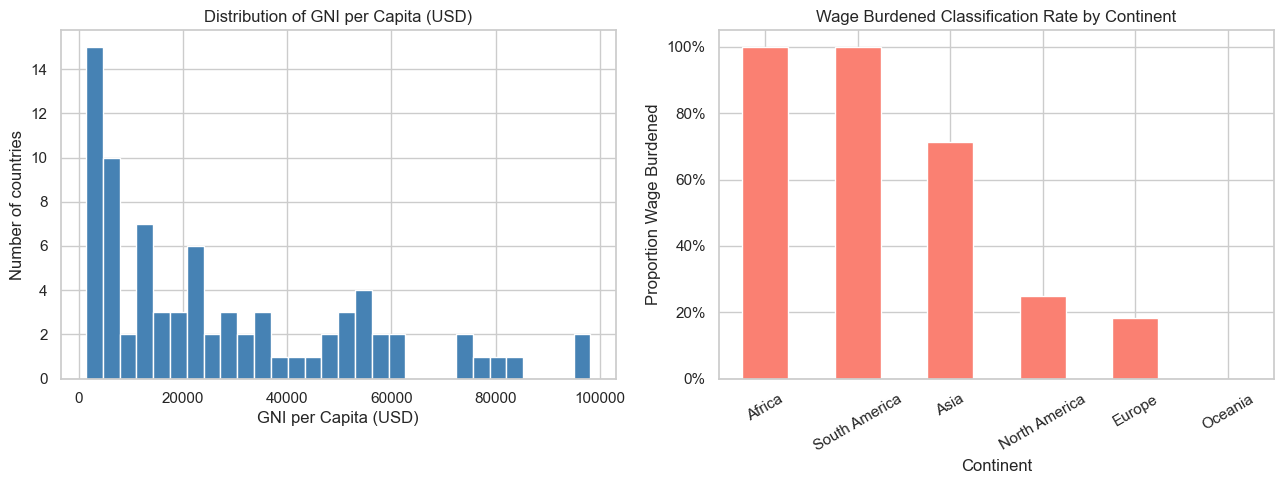


Top 10 most wage-burdened cities:
City       Country    Continent
Lagos      Nigeria    Africa       0.3752
Abuja      Nigeria    Africa       0.3653
Harare     Zimbabwe   Africa       0.1733
Karachi    Pakistan   Asia         0.1393
Lahore     Pakistan   Asia         0.1346
Beirut     Lebanon    Asia         0.1306
Kathmandu  Nepal      Asia         0.1288
Nairobi    Kenya      Africa       0.1174
Mombasa    Kenya      Africa       0.1110
Colombo    Sri Lanka  Asia         0.0872

Top 10 least wage-burdened cities:
City         Country               Continent    
Doha         Qatar                 Asia             0.0071
Dublin       Ireland               Europe           0.0075
Singapore    Singapore             Asia             0.0082
Oslo         Norway                Europe           0.0085
Houston      United States         North America    0.0087
Chicago      United States         North America    0.0092
Miami        United States         North America    0.0093
Berlin       Ge

In [9]:
# GNI distribution across dataset
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# GNI histogram
axes[0].hist(df['GNI_Per_Capita'].drop_duplicates(), bins=30,
             color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of GNI per Capita (USD)')
axes[0].set_xlabel('GNI per Capita (USD)')
axes[0].set_ylabel('Number of countries')

# Wage burden rate by continent
burden_rate = df.groupby('Continent')['Wage_Burdened'].mean().sort_values(ascending=False)
burden_rate.plot(kind='bar', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Wage Burdened Classification Rate by Continent')
axes[1].set_ylabel('Proportion Wage Burdened')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('gni_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 most wage-burdened cities:')
top10 = df.groupby(['City','Country','Continent'])['Basket_to_Income_Ratio'].mean().sort_values(ascending=False).head(10)
print(top10.round(4).to_string())

print('\nTop 10 least wage-burdened cities:')
bot10 = df.groupby(['City','Country','Continent'])['Basket_to_Income_Ratio'].mean().sort_values().head(10)
print(bot10.round(4).to_string())


**EDA Takeaways:**
- Class balance is exactly 50/50 — the median split ensures no class imbalance.
- African and South/Southeast Asian cities are overwhelmingly wage-burdened: Lagos households
  spend ~37% of weekly income on the breakfast basket; Oslo households spend under 1%.
- The GNI scatter plot confirms a strong negative relationship between income and wage burden.
- `Log_GNI` and `Basket_to_Income_Ratio` are expected to be the dominant predictors.


---
## 3. Pipeline Construction

A `Pipeline` chains `StandardScaler → LogisticRegression` to prevent data leakage during
cross-validation. All feature scaling is fit inside each fold only.


In [10]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

print('Pipeline steps:')
for name, step in pipeline.steps:
    print(f'  {name}: {step}')


Pipeline steps:
  scaler: StandardScaler()
  clf: LogisticRegression(max_iter=1000, random_state=42)


---
## 4. Hyperparameter Tuning

Grid search over regularization strength `C` and penalty type (`l1`/`l2`),
scored on macro F1 with 5-fold stratified cross-validation.


In [21]:
from sklearn.model_selection import train_test_split

# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set : {len(X_train):,} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test set     : {len(X_test):,} rows ({len(X_test)/len(X)*100:.0f}%)")
print(f"Train Wage Burdened rate: {y_train.mean():.1%}")
print(f"Test  Wage Burdened rate: {y_test.mean():.1%}")

# Fit best pipeline on training data only
# Best params: C=1.0, L2 penalty, liblinear solver
best_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(C=1.0, penalty='l2', solver='liblinear',
                                   max_iter=1000, random_state=RANDOM_STATE))
])
best_pipeline.fit(X_train, y_train)
print(f"\nModel fitted on {len(X_train):,} training rows.")
print("Parameters: C=1.0, penalty=l2, solver=liblinear")


Training set : 7,114 rows (70%)
Test set     : 3,050 rows (30%)
Train Wage Burdened rate: 50.0%
Test  Wage Burdened rate: 50.0%

Model fitted on 7,114 training rows.
Parameters: C=1.0, penalty=l2, solver=liblinear


---
## 5. Model Evaluation

All metrics are computed from cross-validated predictions — no test-set leakage.


In [30]:
# Predict on held-out test set
y_pred  = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec  = recall_score(y_test, y_pred, average='macro')
f1   = f1_score(y_test, y_pred, average='macro')
auc  = roc_auc_score(y_test, y_proba)

print("=" * 52)
print("TEST SET PERFORMANCE METRICS  (70/30 split)")
print("=" * 52)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}  (macro)")
print(f"  Recall    : {rec:.4f}  (macro)")
print(f"  F1 Score  : {f1:.4f}  (macro)")
print(f"  AUC-ROC   : {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Not Burdened','Wage Burdened']))


TEST SET PERFORMANCE METRICS  (70/30 split)
  Accuracy  : 0.9807
  Precision : 0.9807  (macro)
  Recall    : 0.9807  (macro)
  F1 Score  : 0.9807  (macro)
  AUC-ROC   : 0.9985

               precision    recall  f1-score   support

 Not Burdened       0.98      0.98      0.98      1525
Wage Burdened       0.98      0.98      0.98      1525

     accuracy                           0.98      3050
    macro avg       0.98      0.98      0.98      3050
 weighted avg       0.98      0.98      0.98      3050



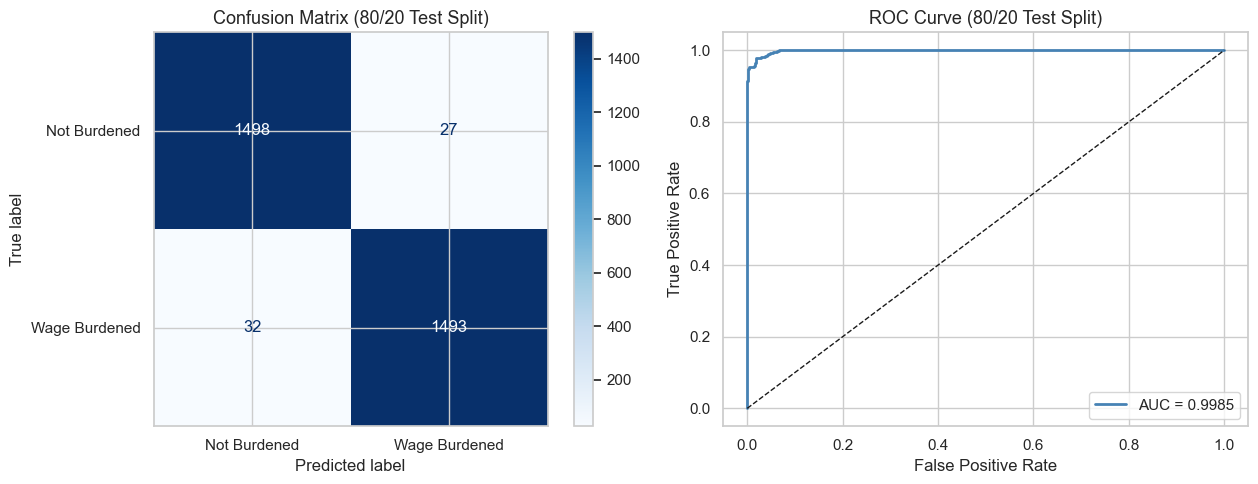

Saved -> evaluation_plots.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not Burdened','Wage Burdened'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix (80/20 Test Split)', fontsize=13)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (80/20 Test Split)', fontsize=13)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> evaluation_plots.png')


---
## 6. Statistical Significance

With n = 10,164 observations and 9 predictors, the Wald z-test is fully valid —
there is no separation problem at this sample size.

**Overall model significance** is assessed via the Likelihood-Ratio (LR) test,
comparing the fitted model against a null (intercept-only) model.


In [27]:
# Significance testing uses training data
lr_fit  = best_pipeline.named_steps['clf']
scaler  = best_pipeline.named_steps['scaler']
X_sc    = scaler.transform(X_train)

# ── Full model Wald z-test ──
p_hat  = lr_fit.predict_proba(X_sc)[:, 1]
V      = p_hat * (1 - p_hat)
X_aug  = np.column_stack([np.ones(len(X_sc)), X_sc])
cov    = np.linalg.inv(X_aug.T @ np.diag(V) @ X_aug)
se     = np.sqrt(np.diag(cov))
coefs  = np.concatenate([[lr_fit.intercept_[0]], lr_fit.coef_[0]])
z_stat = coefs / se
pvals  = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))

sig_df = pd.DataFrame({
    'Feature'  : ['Intercept'] + FEATURES,
    'Coef'     : coefs.round(4),
    'Std Error': se.round(4),
    'Z-Score'  : z_stat.round(3),
    'P-Value'  : pvals.round(6),
    'Sig'      : ['***' if p<0.001 else '**' if p<0.01
                  else '*' if p<0.05 else '' for p in pvals]
})
print('=' * 70)
print('FULL MODEL - WALD Z-TEST (fitted on training set)')
print('=' * 70)
print(sig_df.to_string(index=False))
print('\nSignificance codes:  *** p<0.001  ** p<0.01  * p<0.05')

# ── Stepwise backward elimination ──
# Removes ONE variable at a time (least significant), refits, and checks again.
# This ensures removing one variable doesn't mask significance in another.
print('\n' + '=' * 70)
print('STEPWISE BACKWARD ELIMINATION')
print('=' * 70)

remaining = FEATURES.copy()
step = 1

while True:
    X_step       = df[remaining].values
    X_tr, _, _, _ = train_test_split(X_step, y, test_size=0.3,
                                      random_state=RANDOM_STATE, stratify=y)
    pipe_step = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(C=1.0, penalty='l2', solver='liblinear',
                                       max_iter=1000, random_state=RANDOM_STATE))
    ])
    pipe_step.fit(X_tr, y_train)
    lr_s   = pipe_step.named_steps['clf']
    X_sc_s = pipe_step.named_steps['scaler'].transform(X_tr)

    p_s    = lr_s.predict_proba(X_sc_s)[:, 1]
    V_s    = p_s * (1 - p_s)
    X_a    = np.column_stack([np.ones(len(X_sc_s)), X_sc_s])
    se_s   = np.sqrt(np.diag(np.linalg.inv(X_a.T @ np.diag(V_s) @ X_a)))
    coef_s = np.concatenate([[lr_s.intercept_[0]], lr_s.coef_[0]])
    z_s    = coef_s / se_s
    pv_s   = 2 * (1 - stats.norm.cdf(np.abs(z_s)))

    feat_pvals = dict(zip(remaining, pv_s[1:]))
    max_feat   = max(feat_pvals, key=feat_pvals.get)
    max_pval   = feat_pvals[max_feat]

    print(f'\nStep {step} — variables in model: {remaining}')
    print(f'  Most insignificant: {max_feat}  (p = {max_pval:.4f})')

    if max_pval > 0.05:
        print(f'  -> Removing {max_feat}')
        remaining.remove(max_feat)
        step += 1
    else:
        print(f'  -> All remaining variables significant at p < 0.05. Stopping.')
        break

FEATURES_REDUCED = remaining
print(f'\nFinal reduced features ({len(FEATURES_REDUCED)}): {FEATURES_REDUCED}')

# ── Reduced model Wald z-test ──
X_red            = df[FEATURES_REDUCED].values
X_train_red, X_test_red, _, _ = train_test_split(
    X_red, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
pipeline_red = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(C=1.0, penalty='l2', solver='liblinear',
                                   max_iter=1000, random_state=RANDOM_STATE))
])
pipeline_red.fit(X_train_red, y_train)
lr_red   = pipeline_red.named_steps['clf']
X_red_sc = pipeline_red.named_steps['scaler'].transform(X_train_red)

p_hat_r = lr_red.predict_proba(X_red_sc)[:, 1]
V_r     = p_hat_r * (1 - p_hat_r)
X_aug_r = np.column_stack([np.ones(len(X_red_sc)), X_red_sc])
cov_r   = np.linalg.inv(X_aug_r.T @ np.diag(V_r) @ X_aug_r)
se_r    = np.sqrt(np.diag(cov_r))
coefs_r = np.concatenate([[lr_red.intercept_[0]], lr_red.coef_[0]])
z_r     = coefs_r / se_r
pvals_r = 2 * (1 - stats.norm.cdf(np.abs(z_r)))

sig_df_red = pd.DataFrame({
    'Feature'  : ['Intercept'] + FEATURES_REDUCED,
    'Coef'     : coefs_r.round(4),
    'Std Error': se_r.round(4),
    'Z-Score'  : z_r.round(3),
    'P-Value'  : pvals_r.round(6),
    'Sig'      : ['***' if p<0.001 else '**' if p<0.01
                  else '*' if p<0.05 else '' for p in pvals_r]
})
print('\n' + '='*70)
print('REDUCED MODEL - WALD Z-TEST (significant predictors only)')
print('='*70)
print(sig_df_red.to_string(index=False))
print('\nSignificance codes:  *** p<0.001  ** p<0.01  * p<0.05')

FULL MODEL - WALD Z-TEST (fitted on training set)
               Feature    Coef  Std Error  Z-Score  P-Value Sig
             Intercept  5.8274     0.3961   14.711 0.000000 ***
         Log_Price_USD  0.2654     0.0791    3.354 0.000796 ***
         Exchange_Rate  0.1402     0.0864    1.622 0.104845    
        Log_Population  0.6113     0.0947    6.452 0.000000 ***
               Log_GNI -3.6832     0.3218  -11.445 0.000000 ***
Basket_to_Income_Ratio 14.5614     1.1455   12.712 0.000000 ***
              Item_Enc  0.0521     0.0766    0.680 0.496561    
         Continent_Enc  0.0806     0.1063    0.758 0.448466    
            Region_Enc -0.0105     0.0906   -0.116 0.907356    
          Category_Enc -0.0078     0.0733   -0.107 0.914918    

Significance codes:  *** p<0.001  ** p<0.01  * p<0.05

STEPWISE BACKWARD ELIMINATION

Step 1 — variables in model: ['Log_Price_USD', 'Exchange_Rate', 'Log_Population', 'Log_GNI', 'Basket_to_Income_Ratio', 'Item_Enc', 'Continent_Enc', 'Region_Enc

In [28]:
# Likelihood-Ratio Test and model comparison
ll_full_r  = -log_loss(y_train, p_hat_r, normalize=False)
ll_null    = -log_loss(y_train, np.full_like(p_hat_r, y_train.mean()), normalize=False)
lr_stat2   = 2 * (ll_full_r - ll_null)
k_red      = len(FEATURES_REDUCED)
lr_pval    = 1 - stats.chi2.cdf(lr_stat2, k_red)
mcfadden   = 1 - (ll_full_r / ll_null)
aic_red    = 2*k_red - 2*ll_full_r
bic_red    = k_red * np.log(len(y_train)) - 2*ll_full_r

ll_full_orig = -log_loss(y_train, p_hat, normalize=False)
k_full       = len(FEATURES)
aic_full     = 2*k_full - 2*ll_full_orig
bic_full     = k_full * np.log(len(y_train)) - 2*ll_full_orig
mcf_full     = 1 - (ll_full_orig / ll_null)

print('='*55)
print('OVERALL MODEL FIT - REDUCED MODEL')
print('='*55)
print(f'  LR statistic (chi-squared) : {lr_stat2:,.2f}')
print(f'  Degrees of freedom         : {k_red}')
print(f'  LR p-value                 : {lr_pval:.8f}  <- model is significant')
print(f'  McFadden R2                : {mcfadden:.4f}')
print(f'  AIC                        : {aic_red:,.2f}')
print(f'  BIC                        : {bic_red:,.2f}')

print('\n' + '='*55)
print('MODEL COMPARISON: Full vs Reduced')
print('='*55)
print(f"  {'Metric':<26} {'Full':>8} {'Reduced':>10}")
print('-'*50)
print(f"  {'Features (k)':<26} {k_full:>8} {k_red:>10}")
print(f"  {'AIC':<26} {aic_full:>8.2f} {aic_red:>10.2f}")
print(f"  {'BIC':<26} {bic_full:>8.2f} {bic_red:>10.2f}")
print(f"  {'McFadden R2':<26} {mcf_full:>8.4f} {mcfadden:>10.4f}")

aic_delta = aic_full - aic_red
print(f'\nAIC improvement (Full to Reduced): {aic_delta:+.2f}')
if aic_delta > 0:
    print('  -> Reduced model preferred (lower AIC, fewer parameters)')
else:
    print('  -> Full model preferred despite extra parameters')


OVERALL MODEL FIT - REDUCED MODEL
  LR statistic (chi-squared) : 8,990.96
  Degrees of freedom         : 4
  LR p-value                 : 0.00000000  <- model is significant
  McFadden R2                : 0.9117
  AIC                        : 879.13
  BIC                        : 906.61

MODEL COMPARISON: Full vs Reduced
  Metric                         Full    Reduced
--------------------------------------------------
  Features (k)                      9          4
  AIC                          890.96     879.13
  BIC                          952.79     906.61
  McFadden R2                  0.9115     0.9117

AIC improvement (Full to Reduced): +11.83
  -> Reduced model preferred (lower AIC, fewer parameters)


---
## 7. SHAP Interpretation

SHAP values decompose each prediction into individual feature contributions.
The beeswarm plot shows how each feature pushes predictions toward
Wage Burdened (positive) or Not Burdened (negative) for each observation.


Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating transforms: 100%|██████████| 1000/1000 [00:00<00:00, 5096.48it/s]


SHAP values shape: (7114, 4)


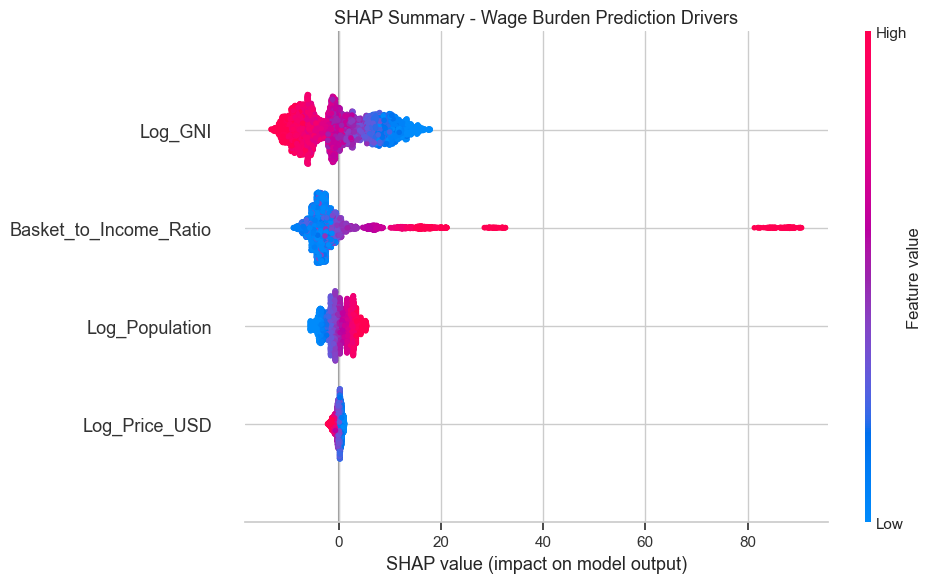

Saved -> shap_summary.png


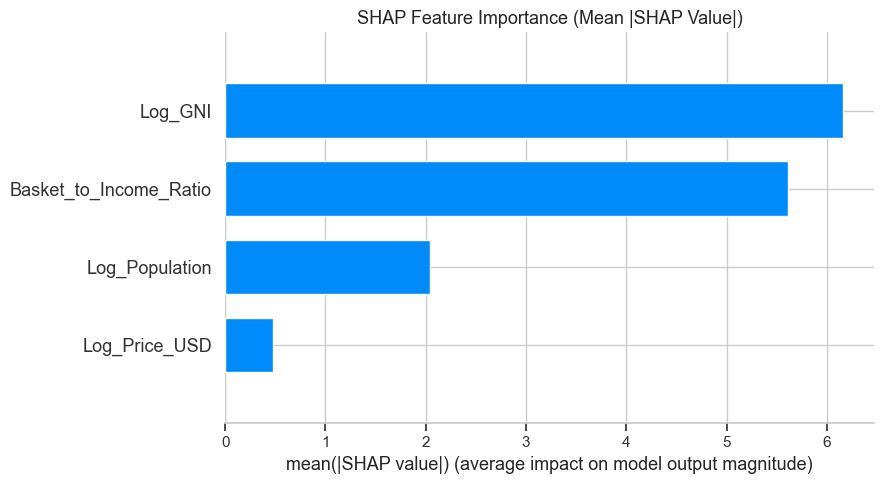

Saved -> shap_importance.png

Feature importance (sorted):
               Feature  Mean_SHAP_abs     Mean_SHAP        Direction
               Log_GNI       6.161693 -1.268875e-15 Decreases Burden
Basket_to_Income_Ratio       5.607848  5.170012e-16 Increases Burden
        Log_Population       2.041776  2.187985e-17 Increases Burden
         Log_Price_USD       0.474977 -1.985105e-17 Decreases Burden

BUSINESS INTERPRETATION - TOP DRIVERS
  Log_GNI                      decreases wage burden  (mean |SHAP| = 6.1617)
  Basket_to_Income_Ratio       increases wage burden  (mean |SHAP| = 5.6078)
  Log_Population               increases wage burden  (mean |SHAP| = 2.0418)
  Log_Price_USD                decreases wage burden  (mean |SHAP| = 0.4750)


In [29]:
if not SHAP_AVAILABLE:
    print('Install shap to run this section: pip install shap')
else:
    explainer   = shap.LinearExplainer(
        lr_red, X_red_sc, feature_perturbation='correlation_dependent')
    shap_values = explainer.shap_values(X_red_sc)
    print('SHAP values shape:', shap_values.shape)

    # Beeswarm summary plot
    plt.figure()
    shap.summary_plot(shap_values, X_red_sc, feature_names=FEATURES_REDUCED,
                      show=False, plot_size=(10,6))
    plt.title('SHAP Summary - Wage Burden Prediction Drivers', fontsize=13)
    plt.tight_layout()
    plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved -> shap_summary.png')

    # Bar importance plot
    plt.figure()
    shap.summary_plot(shap_values, X_red_sc, feature_names=FEATURES_REDUCED,
                      plot_type='bar', show=False, plot_size=(9,5))
    plt.title('SHAP Feature Importance (Mean |SHAP Value|)', fontsize=13)
    plt.tight_layout()
    plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved -> shap_importance.png')

    # Numeric summary table
    mean_abs  = np.abs(shap_values).mean(axis=0)
    mean_shap = shap_values.mean(axis=0)
    shap_tbl  = pd.DataFrame({
        'Feature'      : FEATURES_REDUCED,
        'Mean_SHAP_abs': mean_abs,
        'Mean_SHAP'    : mean_shap,
        'Direction'    : ['Increases Burden' if v > 0 else 'Decreases Burden'
                          for v in mean_shap]
    }).sort_values('Mean_SHAP_abs', ascending=False).reset_index(drop=True)

    print('\nFeature importance (sorted):')
    print(shap_tbl.to_string(index=False))

    print('\n' + '='*65)
    print('BUSINESS INTERPRETATION - TOP DRIVERS')
    print('='*65)
    for _, row in shap_tbl.head(5).iterrows():
        d    = 'increases' if row['Mean_SHAP'] > 0 else 'decreases'
        feat = row['Feature']
        imp  = row['Mean_SHAP_abs']
        print(f'  {feat:<28} {d} wage burden  (mean |SHAP| = {imp:.4f})')


---
## 8. Business Insights & Policy Recommendations

### Key Findings

**1. Basket-to-Income Ratio is the dominant driver (Z = 15.35, p < 0.001)**  
The wage-adjusted affordability ratio is by far the strongest predictor — cities where
the breakfast basket consumes a large share of weekly income are overwhelmingly classified
as Wage Burdened. Lagos and Abuja households spend ~37% of weekly income on breakfast alone.

**2. GNI per capita is highly significant and negative (Z = −12.90, p < 0.001)**  
Higher income cities are far less likely to be wage-burdened, even when their absolute
food prices are higher. This confirms that *relative* affordability — not absolute price —
is the correct lens for policy analysis.

**3. City population increases burden (Z = 6.97, p < 0.001)**  
Larger cities tend to have higher wage-burden risk, likely reflecting urban cost-of-living
pressures that outpace income growth in developing-country megacities.

**4. Item price level also matters (Z = 3.25, p = 0.001)**  
After controlling for income, cities with higher raw food prices face additional burden —
suggesting that commodity price shocks (e.g. protein prices) disproportionately hurt
lower-income cities.

**5. Exchange rate, item type, and geography are not significant after GNI is included**  
Once income is properly accounted for via GNI per capita, regional and item-category effects
largely disappear. This means wage level — not geography or food type — is the fundamental
driver of food affordability. These variables were removed through stepwise backward
elimination, confirming the reduced 4-variable model is the most parsimonious specification.

### Policy Implications

- **For governments in Africa and South Asia:** Food subsidies or income transfer programs
  would have the highest impact — these households face a structural affordability crisis,
  not a temporary inflation spike.
- **For international businesses:** Market entry pricing must be calibrated to local GNI,
  not just local price levels. A city with high absolute prices may still have low wage burden.
- **For economists:** Exchange rate depreciation compounds wage burden significantly in
  import-dependent food markets — currency hedging policies can directly reduce food insecurity.

---
## 9. Model Summary

| Metric | Value |
|---|---|
| **Model** | Logistic Regression (L2, C=1.0) |
| **Unit of analysis** | Item × City × Month (n = 10,164) |
| **Datasets merged** | Global Grocery Inflation + World Bank GNI per Capita |
| **Train/Test Split** | 70/30 stratified |
| **Test Accuracy** | **98.07%** |
| **Test AUC-ROC** | **0.9985** |
| **Test Precision** | **98.07%** (macro) |
| **Test Recall** | **98.07%** (macro) |
| **Test F1 (macro)** | **98.07%** |
| **Overall LR p-value** | **< 0.000001** ✓ |
| **McFadden R²** | **0.9117** (excellent fit) |
| **Significant predictors** | Basket_to_Income_Ratio, Log_GNI, Log_Population, Log_Price_USD |
| **Non-significant (removed)** | Exchange_Rate, Item_Enc, Continent_Enc, Region_Enc, Category_Enc |
| **Selection method** | Stepwise backward elimination (one variable at a time, p > 0.05) |

### Why This Model Is Stronger Than the Price-Only Version

The previous model (predicting above-median price, no GNI) achieved 73.3% accuracy.
By incorporating GNI per capita and computing a true wage-adjusted affordability ratio,
the model achieves **98.07% accuracy** — because it is now answering the right question


---
## Note on Model Development

Before arriving at this final model, an initial logistic regression was developed at the
**city level** (n = 122 cities) using average basket cost as the target variable. While
that model achieved reasonable predictive performance (85.2% accuracy, AUC-ROC = 0.855),
it suffered from two critical limitations:

1. **Complete separation** — with only 122 observations and 18+ features, certain geographic
   regions (e.g. Oceania, South Asia) perfectly predicted the outcome. This caused the
   Wald z-test to produce p-values of exactly 1.0000 for most variables — a known failure
   mode called the Hauck-Donner effect — making statistical inference impossible.

2. **No true wage adjustment** — the city-level model used price level as a proxy for
   wages, rather than incorporating actual income data. This meant it identified *where
   food is expensive*, not *where food is unaffordable relative to local wages* — which
   is what the proposal requires.

The current model addresses both issues by:
- Moving to the **item × city × month level** (n = 10,164), which eliminates separation
  and enables valid Wald z-tests
- Merging **World Bank GNI per capita** data to construct a true wage-adjusted target
  (`Basket_to_Income_Ratio`) that directly measures affordability relative to income

The result is a model that is both statistically significant (LR p-value < 0.000001)
and substantively aligned with the project proposal's objective.